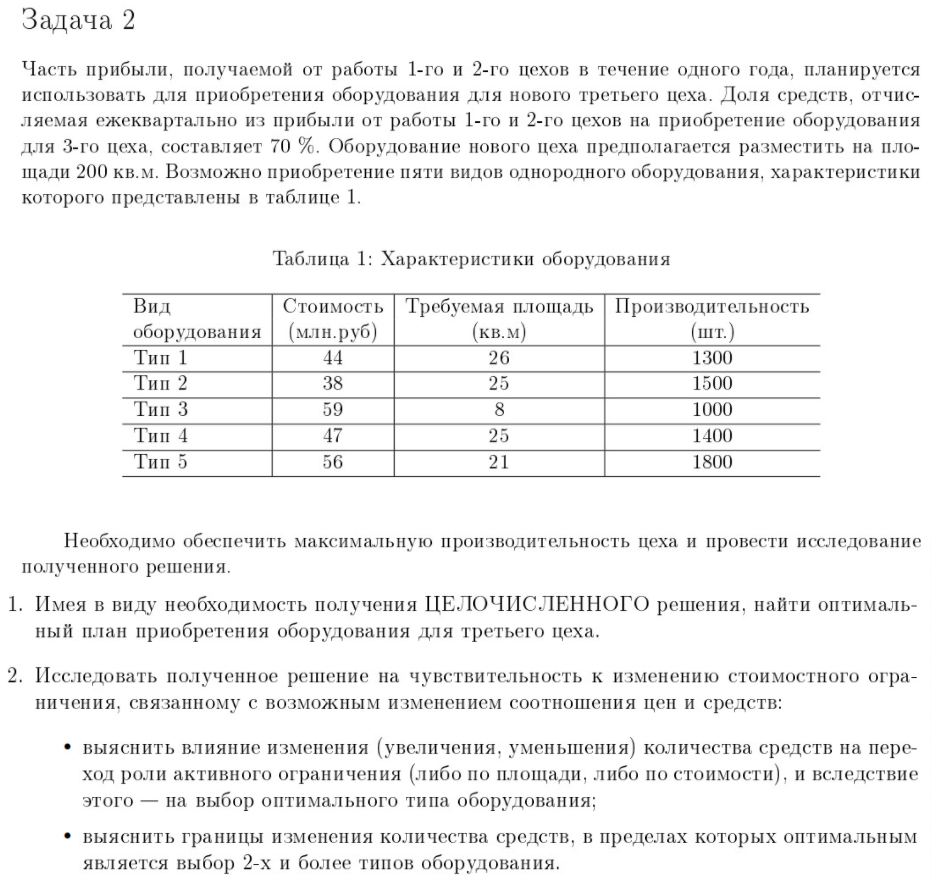

Постановка задачи.

Требуется определить оптимальный план приобретения оборудования для третьего цеха.

Из 1 задачи мы знаем прибыль от цехов за год - 653 млн руб. 70% от прибыли тратится на приобретение оборудования для 3 цеха. Тогда

Бюджет = 653*0.7 = 457.1 ~= 457 млн руб (округление вниз)

Площадь = 200 кв.м

Необходимо закупить разное оборудование таким образом, чтобы не превысить бюджет, площадь и при этом максимизировать производительность.

Формализация задачи.
Пусть:

x1 - количество оборудования типа 1.

x2 - количество оборудования типа 2.

x3 - количество оборудования типа 3.

x4 - количество оборудования типа 4.

x5 - количество оборудования типа 5.

При этом xi >= 0 для i=1,2,3,4,5

Целевая функция F.

F = 1300x1 + 1500x2 + 1000x3 + 1400x4 + 1800x5 -> max

Ограничение по бюджету.

44x1 + 38x2 + 59x3 + 47x4 + 56x5 <= 457

Ограничение по площади.

26x1 + 25x2 + 8x3 + 25x4 + 21x5 <= 200

Полный перебор (naive solution)

In [46]:
def bruteforce(money, area):
    best_value = 0
    best_plan = []
    best_cost = 0
    best_area = 0
    for x1 in range(0, money//44+1):
        for x2 in range(0, money//38+1):
            for x3 in range(0, money//59+1):
                for x4 in range(0, money//47+1):
                    for x5 in range(0, money//56+1):
                        cost = 44*x1 + 38*x2 + 59*x3 + 47*x4 + 56*x5
                        square = 26*x1 + 25*x2 + 8*x3 + 25*x4 + 21*x5
                        if cost <= money and square <= area:
                            value = (1300*x1 + 1500*x2 + 1000*x3 + 1400*x4 + 1800*x5)
                            if value > best_value:
                                best_value = value
                                best_plan = [x1, x2, x3, x4, x5]
                                best_area=square
                                best_cost=cost

    return [best_plan,best_value, best_cost, best_area]
solution = bruteforce(1200, 200) # 457-task, 452 - 1 type and 562 - 1 type
print("Оптимальный план:")
for i in range(len(solution[0])):
    print(f"x{i+1} = ", round(solution[0][i]))
print("Максимальная производительность =", solution[1])
print("Стоимость = ", solution[2])
print("Занятая площадь =", solution[3])

Оптимальный план:
x1 =  0
x2 =  0
x3 =  17
x4 =  0
x5 =  3
Максимальная производительность = 22400
Стоимость =  1171
Занятая площадь = 199


In [17]:
import pulp

F = pulp.LpProblem("Производительность", pulp.LpMaximize)

area=[300,26,25,8,25,21]
money=[300,44,38,59,47,56]

x1 = pulp.LpVariable('x1', lowBound=0, cat='Integer')
x2 = pulp.LpVariable('x2', lowBound=0, cat='Integer')
x3 = pulp.LpVariable('x3', lowBound=0, cat='Integer')
x4 = pulp.LpVariable('x4', lowBound=0, cat='Integer')
x5 = pulp.LpVariable('x5', lowBound=0, cat='Integer')

F += 1300*x1 + 1500*x2 + 1000*x3 + 1400*x4 + 1800*x5
F += 44*x1 + 38*x2 + 59*x3 + 47*x4 + 56*x5 <= 457
F += 26*x1 + 25*x2 + 8*x3 + 25*x4 + 21*x5 <= 200
F.solve()

print("Оптимальный план:")
print("x1 =", int(x1.value()))
print("x2 =", int(x2.value()))
print("x3 =", int(x3.value()))
print("x4 =", int(x4.value()))
print("x5 =", int(x5.value()))
choice = [0,x1.value(), x2.value(), x3.value(), x4.value(), x5.value()]
best_area = 0
best_money = 0
for i in range(1,6):
    best_area+=area[i]*int(choice[i])
    best_money+=money[i]*int(choice[i])

print("Максимальная производительность =", round(pulp.value(F.objective)))
print(f"Потраченна площадь: {best_area} из 200")
print(f"Потрачено денег: {best_money} из 457")

Оптимальный план:
x1 = 0
x2 = 3
x3 = 1
x4 = 0
x5 = 5
Максимальная производительность = 14500
Потраченна площадь: 188 из 200
Потрачено денег: 453 из 457


Так как задача целочисленная, то оба ограничения вряд ли будут строго достигнуты при оптимальном решении. Поэтому проверку на активное ограничение нужно проводить по-другому.

Минимальная стоимость хоть какого-нибудь оборудования 38 млн руб. Минимальная площадь оборудования 8 км.м. Остатки при оптимальном решении: 4 млн руб и 12 кв.м. 

Значит увеличив бюджет, можно будет ещё докупить как минимум 1 единицу оборудования. При этом, если увеличить площадь помещения, то взять оборудование будет невозможно(по деньгам). Это значит, что активным ограниением является именно бюджет, а не площадь.

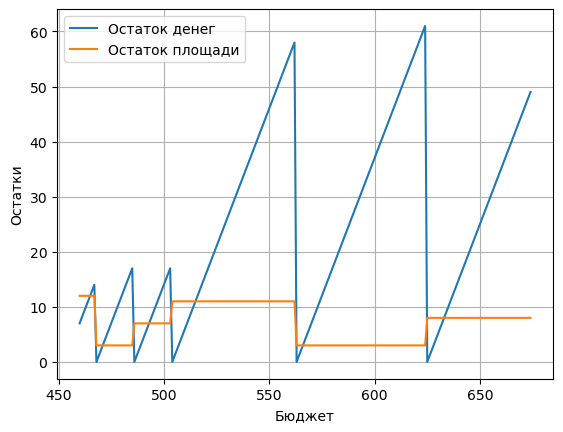

Если значение бюджета достигает 562 млн руб., то оптимальным решением является выбор одного типа оборудования


In [42]:
import matplotlib.pyplot as plt

area = 200
rest_cost = []
rest_area = []
ogr = 0
for B in range(460, 675):
    solution = bruteforce(B, area)
    rest_cost.append(B-solution[2])
    rest_area.append(200-solution[3])
    k = 0
    for i in range(5):
        if solution[0][i] != 0: k+=1
    if k < 2: ogr = B
    
    
plt.figure()
plt.plot(range(460,675),rest_cost, label="Остаток денег")
plt.plot(range(460,675),rest_area, label="Остаток площади")
plt.xlabel("Бюджет")
plt.ylabel("Остатки")
plt.legend()
plt.grid()
plt.show()

print(f"Если значение бюджета достигает {ogr} млн руб., то оптимальным решением является выбор одного типа оборудования")

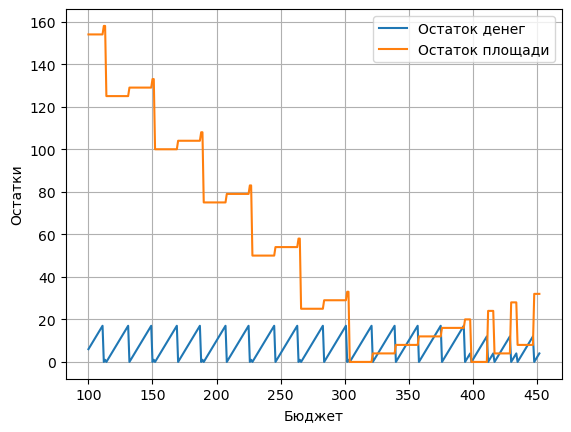

Если значение бюджета упадёт до 452 млн руб., то оптимальным решением является выбор одного типа оборудования


In [41]:
import matplotlib.pyplot as plt

area = 200
rest_cost = []
rest_area = []
ogr = 0
for B in range(100, 453):
    solution = bruteforce(B, area)
    rest_cost.append(B-solution[2])
    rest_area.append(200-solution[3])
    k = 0
    for i in range(5):
        if solution[0][i] != 0: k+=1
    if k < 2: ogr = B
    
    
plt.figure()
plt.plot(range(100,453),rest_cost, label="Остаток денег")
plt.plot(range(100,453),rest_area, label="Остаток площади")
plt.xlabel("Бюджет")
plt.ylabel("Остатки")
plt.legend()
plt.grid()
plt.show()

print(f"Если значение бюджета упадёт до {ogr} млн руб., то оптимальным решением является выбор одного типа оборудования")

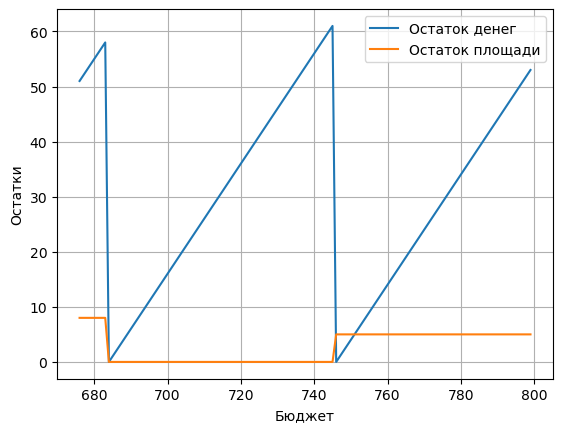

In [43]:
import matplotlib.pyplot as plt

area = 200
rest_cost = []
rest_area = []
ogr = 0
for B in range(676, 800):
    solution = bruteforce(B, area)
    rest_cost.append(B-solution[2])
    rest_area.append(200-solution[3])
    
    
plt.figure()
plt.plot(range(676,800),rest_cost, label="Остаток денег")
plt.plot(range(676,800),rest_area, label="Остаток площади")
plt.xlabel("Бюджет")
plt.ylabel("Остатки")
plt.legend()
plt.grid()
plt.show()